In [1]:
from FastCCM import CCM, CCM_utils
from FastCCM.utils import utils
import importlib
import numpy as np
import matplotlib.pyplot as plt
importlib.reload(CCM)
importlib.reload(utils)
import pandas as pd
import os
import umap
import igraph as ig
from sklearn.decomposition import PCA
import time
from scipy.cluster.hierarchy import linkage, dendrogram
import plotly.express as px
from sklearn.metrics.pairwise import pairwise_distances

from sklearn.preprocessing import StandardScaler

2025-02-04 10:32:06.083777: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-04 10:32:06.109837: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-02-04 10:32:06.591021: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
import torch
torch.cuda.empty_cache()

In [219]:
# Load traffic dataset
X = np.load("../src/FastCCM/data/datasets/llm_data.npy")
X = StandardScaler().fit_transform(X)
X = X[:6000]

In [220]:
ccm = CCM.PairwiseCCM(device="cuda")

In [221]:

optimal_tau = []
optimal_E = []
value = []

for id in range(X.shape[1]):
    optimal_E_tau_res = CCM_utils.Functions("cuda").find_optimal_embedding_params(X[:,id], X[:,id], 700, 150, exclusion_rad=10,
                                                            E_range=np.arange(1,20),
                                                            tau_range=np.arange(1,10,1),
                                                            tp_max=10,
                                                            method="simplex",trials=2)
    
    optimal_tau += [optimal_E_tau_res["optimal_tau"]]
    optimal_E += [optimal_E_tau_res["optimal_E"],]
    value  += [optimal_E_tau_res["values"].mean()]
    print(id)
    
np.save("llm_results/optimal_E.npy", np.array(optimal_E))
np.save("llm_results/optimal_tau.npy", np.array(optimal_tau))
np.save("llm_results/optimal_E_tau_rho.npy", np.array(value))

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [222]:
optimal_E = np.load("llm_results/optimal_E.npy")
optimal_tau = np.load("llm_results/optimal_tau.npy")
value = np.load("llm_results/optimal_E_tau_rho.npy")


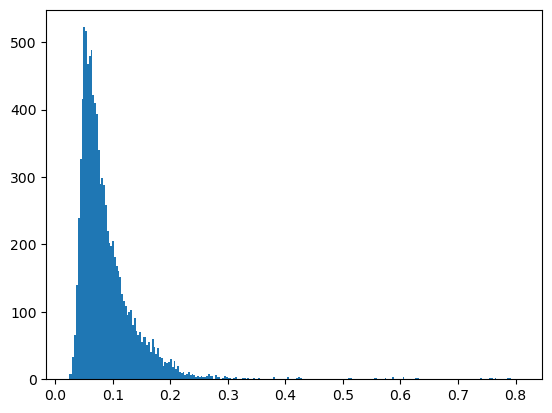

In [223]:
plt.hist(value,bins=250)
plt.show()

In [224]:


import plotly.graph_objects as go
fig = go.Figure(
    data=go.Scatter3d(
        x=x_pca[:-1, 0],
        y=x_pca[:-1, 1],
        z=x_pca[:-1, 2],
        mode='lines',
        line=dict(
            color=compute_speed_of_rotation(x_pca,np.arange(0,unmixed.shape[0])/25)[0],  # Color by order
            colorscale='Viridis',  # Choose a colorscale
            colorbar=dict(title='Velocity'),  # Add colorbar
            width=4  # Line width
        )
    )
)
# Update layout for better visualization
fig.update_layout(
    scene=dict(
        xaxis_title='PC1',
        yaxis_title='PC2',
        zaxis_title='PC3'
    ),
    height=700
)
fig.show()

array([3159,   19,  442,  762, 1995, 2281, 1227, 6999,  213,  402,  459,
        365,  107,  497,  554,  314,  655, 1754,  479, 7392,  408,  525,
       8928, 2016,  839,  986, 8160,  455, 5088,  430,   49, 1607,  496,
       6624, 1248, 2784, 4320, 3552, 5856,  374])

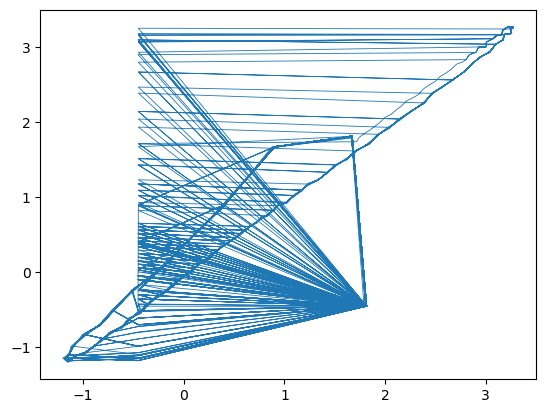

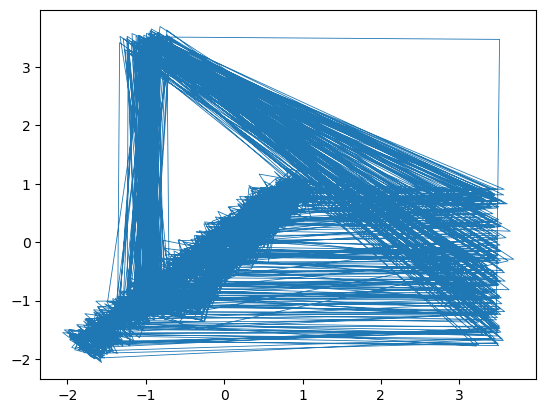

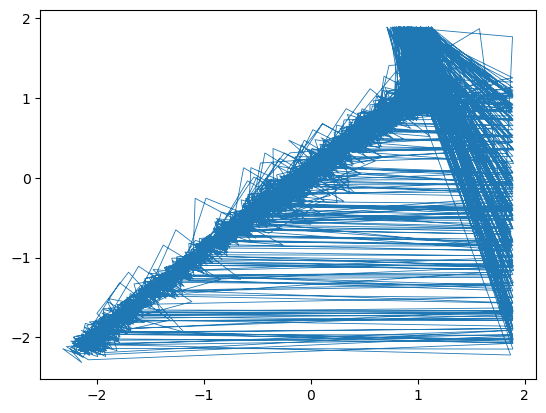

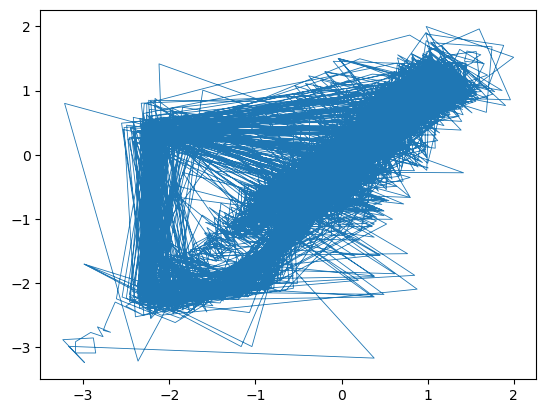

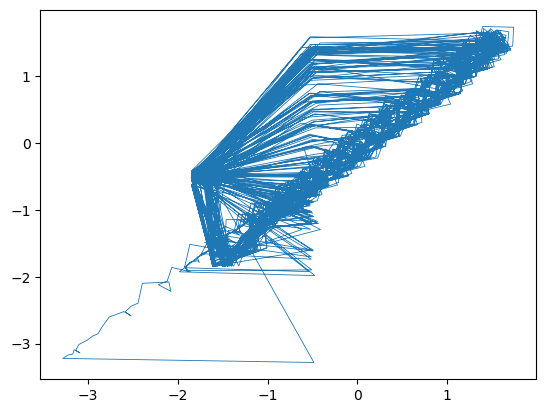

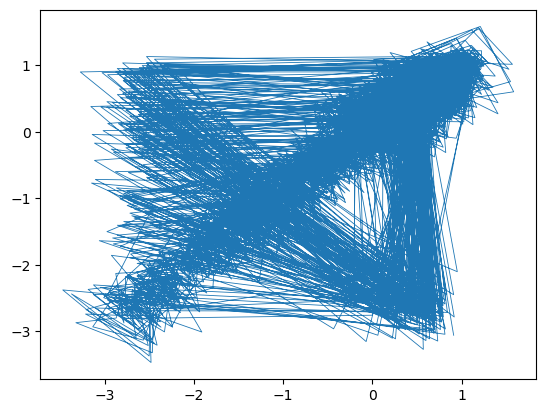

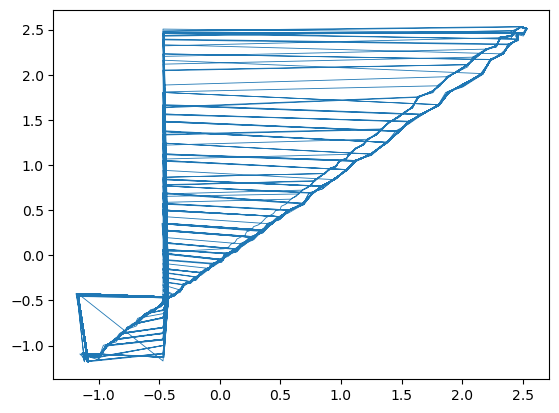

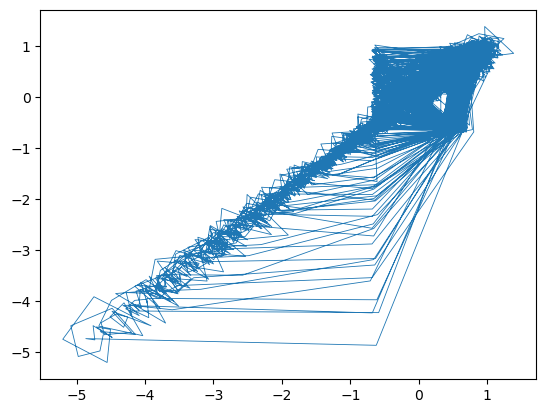

In [243]:
plt.plot(X[1:,496],X[:-1,496],lw=0.6)
plt.show()
plt.plot(X[1:,271],X[:-1,271],lw=0.6)
plt.show()
plt.plot(X[1:,107],X[:-1,107],lw=0.6)
plt.show()
plt.plot(X[1:,554],X[:-1,554],lw=0.6)
plt.show()
plt.plot(X[1:,314],X[:-1,314],lw=0.6)
plt.show()
plt.plot(X[1:,455],X[:-1,455],lw=0.6)
plt.show()
plt.plot(X[1:,430],X[:-1,430],lw=0.6)
plt.show()
plt.plot(X[1:,8928],X[:-1,8928],lw=0.6)

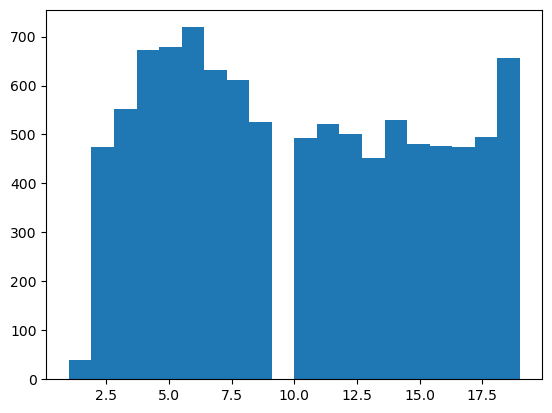

In [226]:
plt.hist(optimal_E,bins=20)
plt.show()

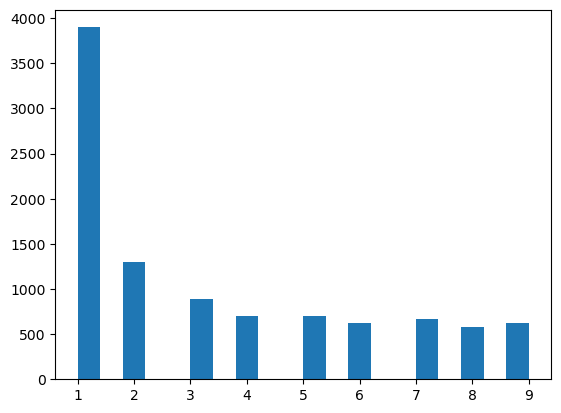

In [246]:
plt.hist(optimal_tau,bins=20)
plt.show()

In [248]:
st = time.time()
fp = np.memmap('llm_results/full_ccm_matrix.dat', dtype='float16', mode='w+', shape=(X.shape[1], X.shape[1]))
blocksize_X = 200
blocksize_Y = 200
for i in range(0, X.shape[1], blocksize_Y):
    for j in range(0, X.shape[1], blocksize_X):
        X_emb = np.array([utils.get_td_embedding_np(X[:,[k]],optimal_E[k],optimal_tau[k])[:,:,0] for k in range(j,min(j+blocksize_X, X.shape[1]))],dtype=object)
        Y_emb = np.array([X[:,[k]] for k in range(i,min(i+blocksize_Y, X.shape[1]))])
        block = ccm.compute(X_emb,Y_emb,subset_size=700,subsample_size=150,exclusion_rad=10,tp=0,method="simplex")[0].astype(np.float16)
        
        fp[i:i+blocksize_Y, j:j+blocksize_X] = block
    
    print(i)

fp.flush()
del fp
print(time.time()-st)

0
200
400
600
800
1000
1200
1400
1600
1800
2000
2200
2400
2600
2800
3000
3200
3400
3600
3800
4000
4200
4400
4600
4800
5000
5200
5400
5600
5800
6000
6200
6400
6600
6800
7000
7200
7400
7600
7800
8000
8200
8400
8600
8800
9000
9200
9400
9600
9800
182.33812403678894


In [247]:
st = time.time()
fp = np.memmap('llm_results/full_corr_matrix.dat', dtype='float16', mode='w+', shape=(X.shape[1], X.shape[1]))
blocksize = 1000
for i in range(0, X.shape[1], blocksize):
    for j in range(0, X.shape[1], blocksize):
        X_emb = X[:,i:min(i+blocksize, X.shape[1])]
        Y_emb = X[:,j:min(j+blocksize, X.shape[1])]
        block = np.corrcoef(X_emb.T,Y_emb.T)[:X_emb.shape[1],X_emb.shape[1]:].astype(np.float16)
        fp[i:i+blocksize, j:j+blocksize] = block
    
    print(i)

fp.flush()
del fp
print(time.time()-st)

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
15.049722909927368


In [249]:
ccm_matrix = np.memmap('llm_results/full_ccm_matrix.dat', dtype="float16", mode='r',shape=(X.shape[1], X.shape[1]))
corr_matrix = np.memmap('llm_results/full_corr_matrix.dat', dtype="float16", mode='r', shape=(X.shape[1], X.shape[1]))
fp = np.memmap('llm_results/full_rhodiff_matrix.dat', dtype='float16', mode='w+', shape=(X.shape[1], X.shape[1]))
blocksize = 1000
for i in range(0, X.shape[1], blocksize):
    for j in range(0, X.shape[1], blocksize):
        block = ccm_matrix[i:min(i+blocksize, X.shape[1]), j:min(j+blocksize, X.shape[1])] - np.abs(corr_matrix[i:min(i+blocksize, X.shape[1]), j:min(j+blocksize, X.shape[1])])
        fp[i:i+blocksize, j:j+blocksize] = block
    
    print(i)

fp.flush()
del fp


0
1000
2000
3000
4000
5000
6000
7000
8000
9000


In [250]:
ccm_matrix = np.memmap('llm_results/full_ccm_matrix.dat', dtype="float16", mode='r', shape=(X.shape[1], X.shape[1]))
corr_matrix = np.memmap('llm_results/full_corr_matrix.dat', dtype="float16", mode='r', shape=(X.shape[1], X.shape[1]))
rhodiff_matrix = np.memmap('llm_results/full_rhodiff_matrix.dat', dtype="float16", mode='r', shape=(X.shape[1], X.shape[1]))
#mm = np.load('traffic_results/mask.npy')

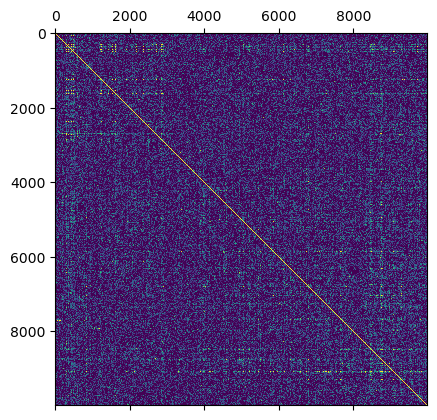

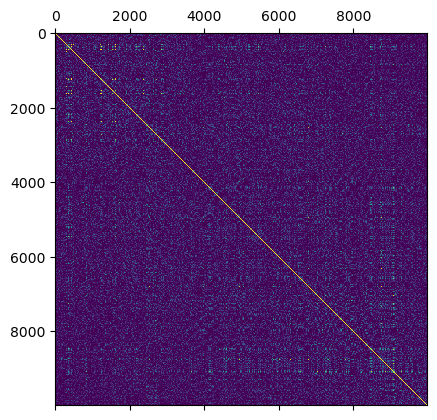

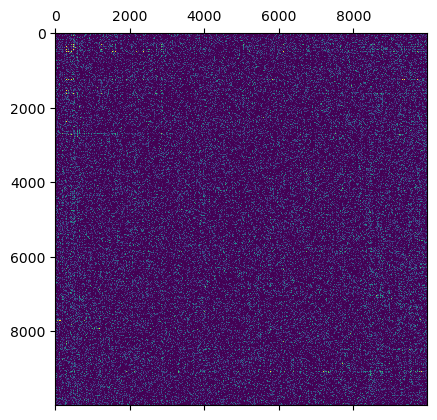

In [251]:

plt.matshow(ccm_matrix,vmin=0,vmax=0.4)
plt.matshow(corr_matrix,vmin=0,vmax=0.4)
plt.matshow(rhodiff_matrix,vmin=0,vmax=0.4)

In [253]:
#d = (np.triu(rho_diff) - np.tril(rho_diff).T)+(np.triu(rho_diff) - np.tril(rho_diff).T).T
d = np.max([np.triu(rhodiff_matrix).flatten(), np.tril(rhodiff_matrix).T.flatten()],axis=0)
d = d.reshape(rhodiff_matrix.shape)
d += d.T
d[d<0] = 0

/home/iaroslav/miniconda3/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.

/home/iaroslav/miniconda3/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.



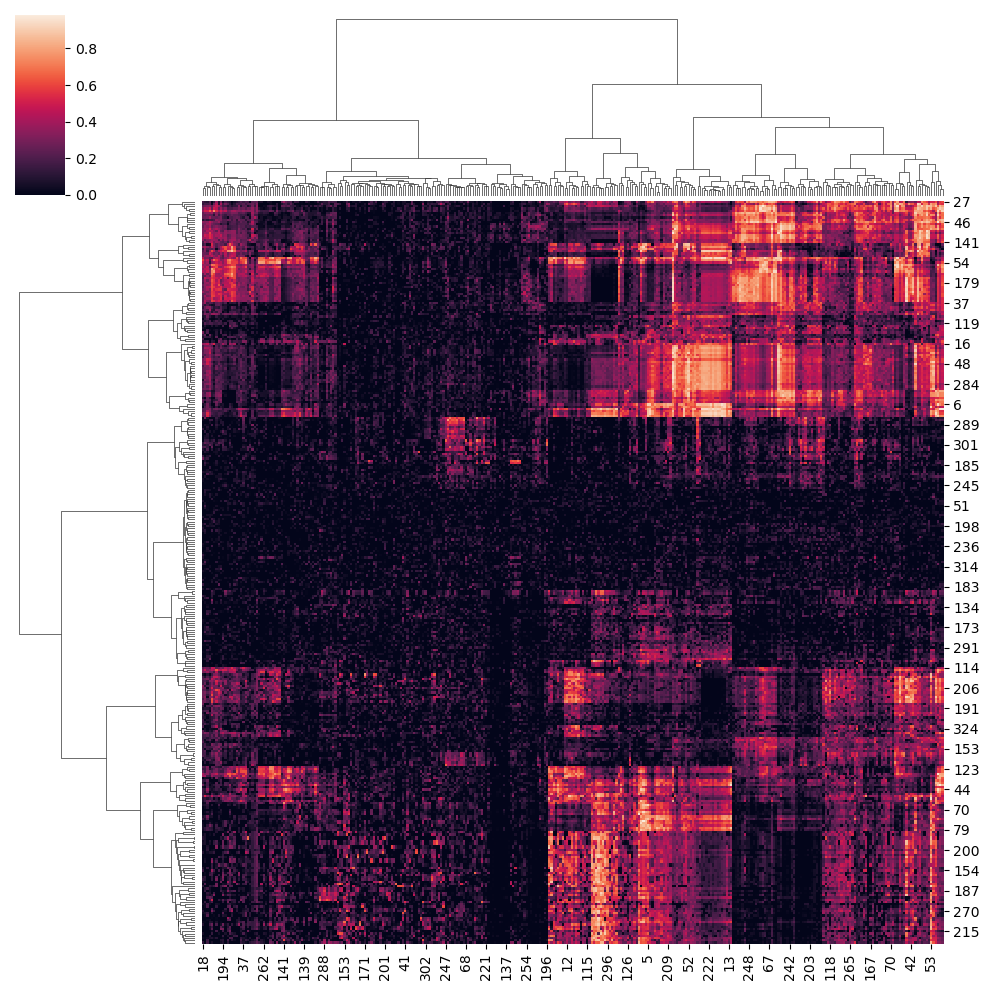

In [291]:

import seaborn as sns

sns.clustermap(rhodiff_matrix[(d.max(axis=0) > 0.6)][:,(d.max(axis=0) > 0.6)],method="ward",vmin=0)

In [255]:
np.argsort(rhodiff_matrix[1146])

memmap([8774, 1913, 1897, ..., 7392, 4320,  762])

In [256]:
np.argsort(rhodiff_matrix[:,1146])

memmap([3550, 1129, 4632, ...,  213,  762, 2000])

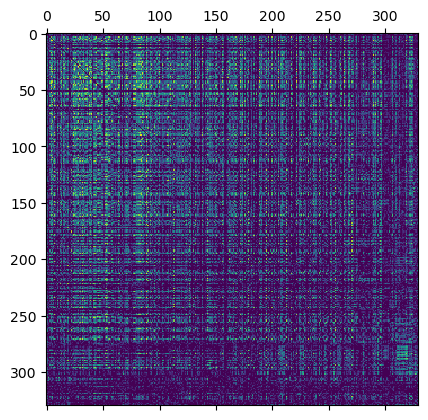

In [292]:
plt.matshow(rhodiff_matrix[(d.max(axis=0) > 0.6)][:,(d.max(axis=0) > 0.6)],vmin=0)

In [259]:

from sklearn.cluster import DBSCAN

u = umap.UMAP(25,2,min_dist=0.15)
embedding__ = u.fit_transform(rhodiff_matrix[(d.max(axis=0) > 0.5)][:,(d.max(axis=0) > 0.5)])

# Perform DBSCAN clustering on the embedding.
# Adjust eps and min_samples according to your data.
dbscan_model = DBSCAN(eps=0.5, min_samples=5)
cluster_labels = dbscan_model.fit_predict(embedding__)

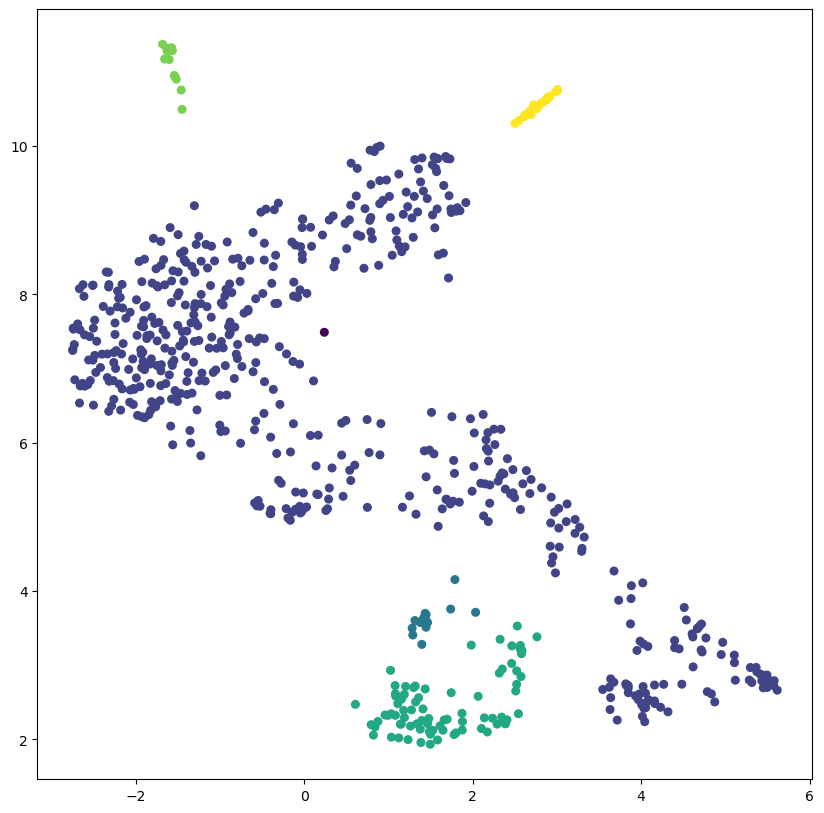

In [260]:
plt.figure(figsize=(10,10))
plt.scatter(x=embedding__[:,0],y=embedding__[:,1],c=cluster_labels,s=30)

In [270]:
np.where((d.max(axis=0) > 0.5))[0][(cluster_labels==4)]

array([8407, 8447, 8452, 8457, 8473, 8487, 8491, 8494, 8502, 8525, 8528,
       8531, 8539, 8550, 8555, 8563, 8572, 8580, 8582, 8592, 8593])

In [263]:
np.unique(cluster_labels)

array([-1,  0,  1,  2,  3,  4])

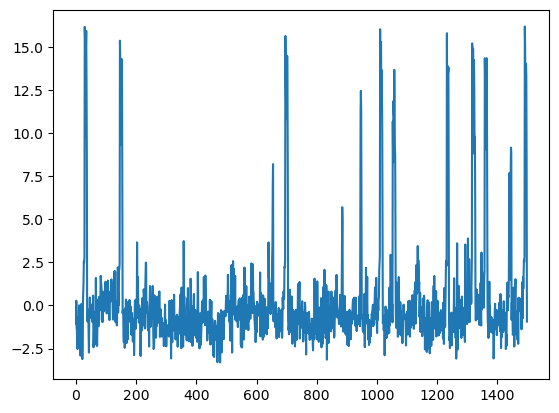

In [294]:
plt.plot(PCA(2).fit_transform(X[:,[8407, 8447, 8452, 8457, 8473, 8487, 8491, 8494, 8502, 8525, 8528,
       8531, 8539, 8550, 8555, 8563, 8572, 8580, 8582, 8592, 8593]])[:1500,0])

(0.0, 500.0)

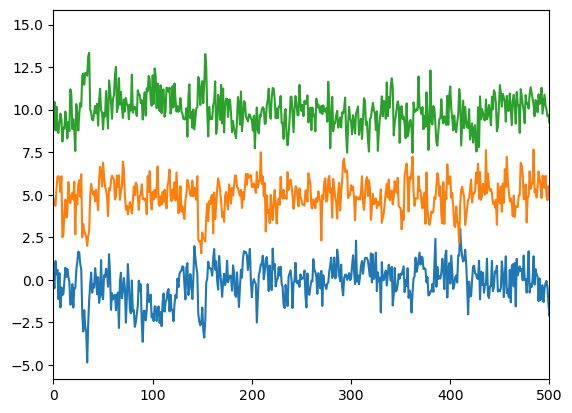

In [271]:
plt.plot(X[:,8407])
plt.plot(X[:,8447]+5)
plt.plot(X[:,8452]+10)
plt.xlim(0,500)